In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sqlalchemy import create_engine
import os
from dotenv import load_dotenv

sns.set_theme(style="whitegrid")
pd.set_option('display.max_columns', None)

load_dotenv('../ingestion/.env')  # reuse .env to prevent leak
os.getcwd()

'c:\\Users\\Alvin\\Music\\project_1\\notebook'

In [2]:
# Koneksi ke Postgres, baca langsung dari tabel marts hasil dbt
DB_USER = os.getenv("DB_USER", "alvin")
DB_PASSWORD = os.getenv("DB_PASSWORD")
DB_HOST = os.getenv("DB_HOST", "localhost")
DB_PORT = os.getenv("DB_PORT", "5432")
DB_NAME = os.getenv("DB_NAME", "price_intelligence")

engine = create_engine(f"postgresql://{DB_USER}:{DB_PASSWORD}@{DB_HOST}:{DB_PORT}/{DB_NAME}")

#Schema: 'public' fact table from mart
df_raw = pd.read_sql("SELECT * FROM public.fct_ebay_listings", engine)

print(f"Total baris: {len(df_raw)}")
df_raw.head()

Total baris: 1813


,item_id,title,price,currency,condition,seller_location,volume_number,volume_number_end,is_boxset,boxset_side_story_edition_included,standalone_side_story_edition,is_special_edition,total_risk_score,risk_category,fetched_at
0,v1|115965603147|0,Spy Classroom Volumes 1-3 Light Novel Set New ...,40.50,USD,Brand New,US,1.0,3.0,True,False,False,False,0,Low Risk,2026-08-07 16:24:49.572937
1,v1|116263745717|0,"Gimai Seikatsu, Days with My Step Sister Light...",149.90,USD,Brand New,MY,1.0,8.0,True,False,False,False,70,High Risk,2026-08-07 16:24:49.572937
2,v1|116268231670|0,"Bofuri: I Don't Want to Get Hurt, so I'll Max ...",17.20,USD,Brand New,US,13.0,NaN,False,False,False,False,0,Low Risk,2026-08-07 16:24:49.572937
3,v1|117165076117|0,"Overlord, Vol. 6 (light Novel) : The Men of th...",16.49,USD,Brand New,US,6.0,NaN,False,False,False,False,0,Low Risk,2026-08-07 16:24:49.572937
4,v1|117235695074|0,Classroom of the Elite (Light Novel) Year 1 Vo...,75.00,USD,Good,US,7.0,NaN,False,False,False,False,0,Low Risk,2026-08-07 16:24:49.572937


#### A.1 Data Inspection

In [9]:
df_raw.describe()

,price,volume_number,volume_number_end,total_risk_score,fetched_at
count,1813.000000,1458.000000,508.000000,1813.00000,1813
mean,68.061671,4.371742,14.653543,13.89134,2026-08-07 16:12:35.487573
min,2.490000,0.000000,2.000000,0.00000,2026-08-06 11:58:32.898800
25%,13.350000,1.000000,8.000000,0.00000,2026-08-07 16:24:49.572937
50%,21.620000,2.000000,13.000000,0.00000,2026-08-07 16:24:49.572937
75%,98.000000,6.000000,19.000000,0.00000,2026-08-07 16:24:49.572937
max,1999.000000,75.000000,45.000000,100.00000,2026-08-07 16:24:49.572937
std,102.849310,5.381692,8.535692,27.91031,NaN


In [3]:
missing_summary = df_raw.isnull().sum().to_frame('missing_count')
missing_summary['missing_%'] = (missing_summary['missing_count'] / len(df_raw) * 100).round(1)
missing_summary.sort_values('missing_count', ascending=False)

,missing_count,missing_%
volume_number_end,1305,72.0
volume_number,355,19.6
condition,16,0.9
price,0,0.0
title,0,0.0
currency,0,0.0
item_id,0,0.0
seller_location,0,0.0
is_boxset,0,0.0
boxset_side_story_edition_included,0,0.0


In [4]:
print(f"risk_category distribution (all):{df_raw['risk_category'].value_counts()}")

df_price_model = df_raw[df_raw['risk_category'] != 'High Risk']
print(f"risk_category distribution (w/0 high risk): {df_price_model['risk_category'].value_counts()}")

risk_category distribution (all):risk_category
Low Risk     1498
High Risk     315
Name: count, dtype: int64
risk_category distribution (w/0 high risk): risk_category
Low Risk    1498
Name: count, dtype: int64


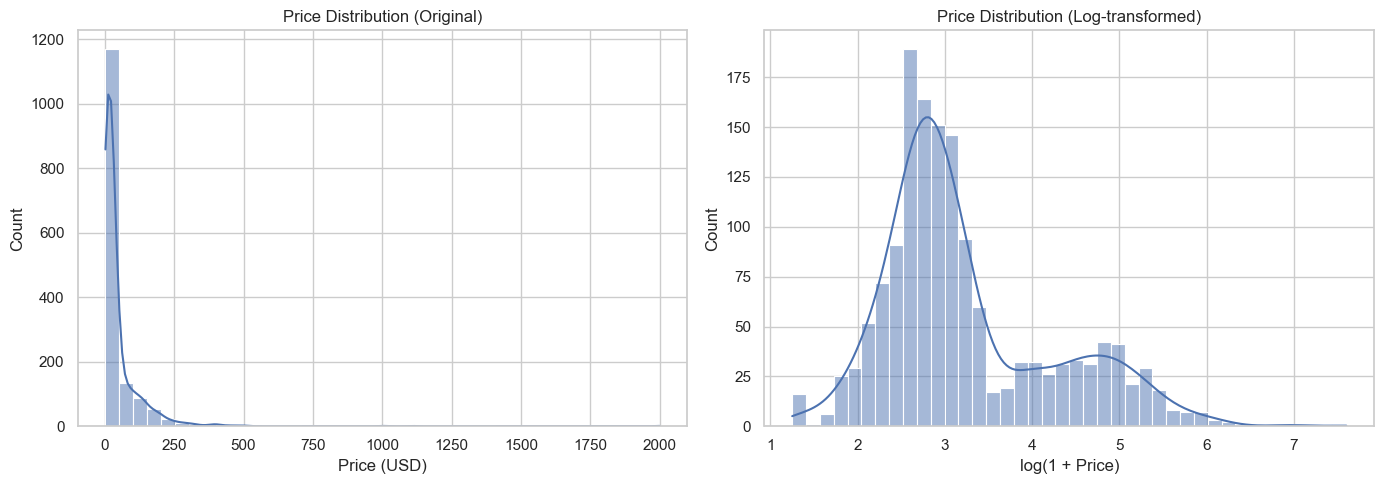

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(df_price_model['price'], bins=40, kde=True, ax=axes[0])
axes[0].set_title('Price Distribution (Original)')
axes[0].set_xlabel('Price (USD)')

sns.histplot(np.log1p(df_price_model['price']), bins=40, kde=True, ax=axes[1])
axes[1].set_title('Price Distribution (Log-transformed)')
axes[1].set_xlabel('log(1 + Price)')

plt.tight_layout()
plt.show()

In [ ]:
print(df_price_model['price'].describe())

print(np.log1p(df_price_model['price']).describe())

count    1498.000000
mean       46.653625
std        89.634045
min         2.490000
25%        12.950000
50%        17.965000
75%        39.990000
max      1999.000000
Name: price, dtype: float64
count    1498.000000
mean        3.234409
std         0.985247
min         1.249902
25%         2.635480
50%         2.942595
75%         3.713328
max         7.600902
Name: price, dtype: float64


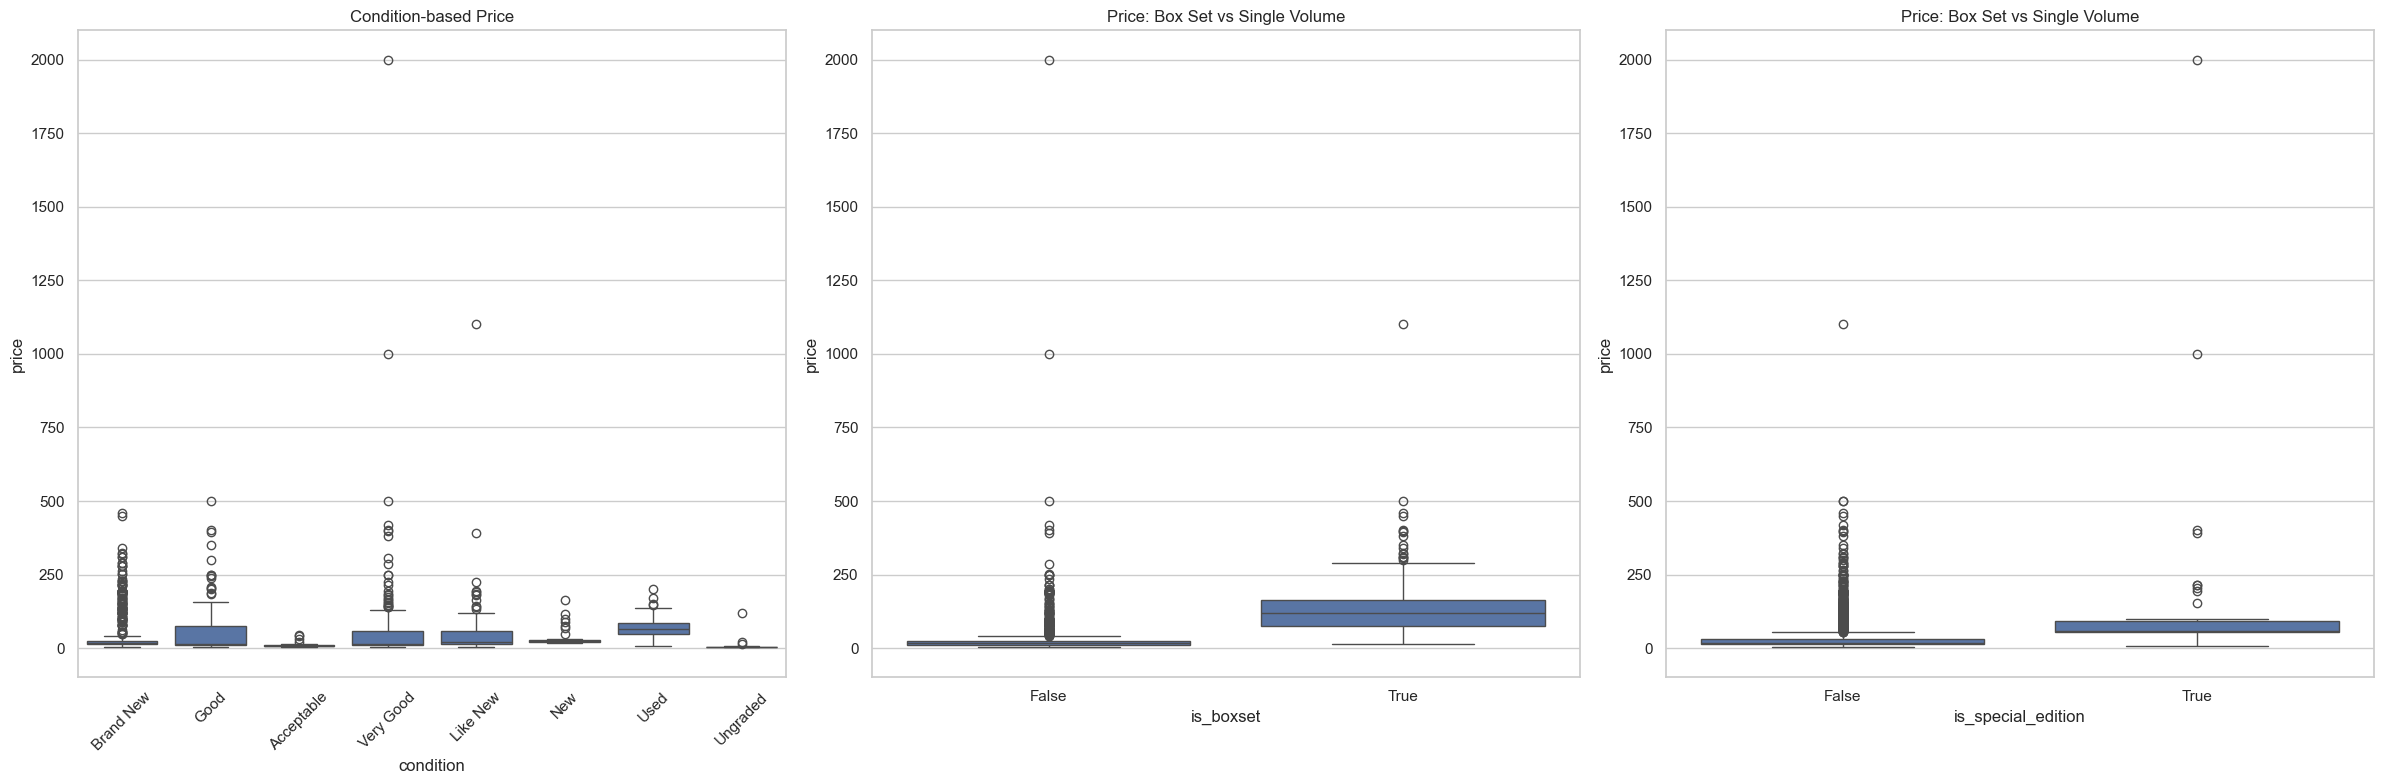

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(24, 8))

sns.boxplot(data=df_price_model, x='condition', y='price', ax=axes[0])
axes[0].set_title('Condition-based Price')
axes[0].tick_params(axis='x', rotation=45)

sns.boxplot(data=df_price_model, x='is_boxset', y='price', ax=axes[1])
axes[1].set_title('Price: Box Set vs Single Volume')

sns.boxplot(data=df_price_model, x='is_special_edition', y='price', ax=axes[2])
axes[2].set_title('Price: Box Set vs Single Volume')

plt.tight_layout()
plt.show()

In [14]:
df_price_model[df_price_model['price'] > 250].head(5)

,item_id,title,price,currency,condition,seller_location,volume_number,volume_number_end,is_boxset,boxset_side_story_edition_included,standalone_side_story_edition,is_special_edition,total_risk_score,risk_category,fetched_at
19,v1|125075935916|429071507693,Re:Zero: Starting Life in Another World Vol.1-...,458.88,USD,Brand New,JP,1.0,44.0,True,False,False,False,0,Low Risk,2026-08-07 16:24:49.572937
41,v1|127843243167|0,"Overlord 1,3-8,10, 12,13,16 Light Novel New En...",252.00,USD,Brand New,US,NaN,NaN,False,False,False,False,0,Low Risk,2026-08-07 16:24:49.572937
43,v1|127898400680|0,Classroom of the Elite Light Novel Complete Se...,449.99,USD,Brand New,US,1.0,11.0,True,True,False,False,0,Low Risk,2026-08-07 16:24:49.572937
112,v1|147237499460|0,Mushoku Tensei Jobless Reincarnation Light Nov...,398.78,USD,Very Good,JP,1.0,26.0,True,False,False,False,0,Low Risk,2026-08-07 16:24:49.572937
152,v1|154976745230|0,Mushoku Tensei Volume 1- 26 complete Light Nov...,399.99,USD,Good,JP,1.0,26.0,True,False,False,False,0,Low Risk,2026-08-07 16:24:49.572937


In [11]:
for col in ['condition', 'seller_location']:
    print(f"{col}: {df_price_model[col].nunique()} kategori unik")
    print(df_price_model[col].value_counts())
    print()

condition: 8 kategori unik
condition
Brand New     647
Good          283
Very Good     208
Like New      168
New            62
Acceptable     45
Used           41
Ungraded       28
Name: count, dtype: int64

seller_location: 7 kategori unik
seller_location
US    1146
JP     231
MY      46
GB      33
AU      30
CA      11
DE       1
Name: count, dtype: int64

